In [1]:
# basic modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# train test split
from sklearn.model_selection import train_test_split

# preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import FunctionTransformer


# pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# linear regression
from sklearn.linear_model import LinearRegression, LogisticRegression

# XGBOOST
from xgboost import XGBClassifier
from xgboost import XGBRegressor

# random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

# permutation importance
from sklearn.inspection import permutation_importance

# shap
import shap

# metrics
from sklearn.metrics import silhouette_score
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import sys


# graphics
from sklearn.tree import plot_tree

# settings
pd.set_option('display.float_format', '{:.2f}'.format)


c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load data

df = pd.read_csv(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features_target.csv"
)

print(df.shape)

embeddings_all = np.load(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/embeddings.npy")


(57529, 32)


In [3]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success',
       'topic_name', 'target_cost_log'],
      dtype='str')

In [4]:
df.dtypes

conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
follow_up_prompts                      int64
needs_follow_up                        int64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
topic                                  int64
topic_prob                           float64
topic_labe

In [5]:
# dtypes    ### !!! auch in feature_target... könnte bei neuem Durchlaufen entfernt werden.

df["prompt_style"]=df["prompt_style"].astype("category")
df["task_type"]=df["task_type"].astype("category")
df["target_success"]=df["target_success"].astype("int")

#df.dtypes

In [6]:
# Falls ich diese filtere, stimmen evtl. Embeddings nicht mehr mit df überein...? filter other languages with orthographic error rate

# OER = 0.40

# outliers_oer = df[df["orthographic_error_rate"] > OER]   
# print(outliers_oer)    # n=247

# print

# pd.set_option("display.max_rows", None)


# df = df[df["orthographic_error_rate"] < OER]
# print(len(df))    # n=247


<Axes: >

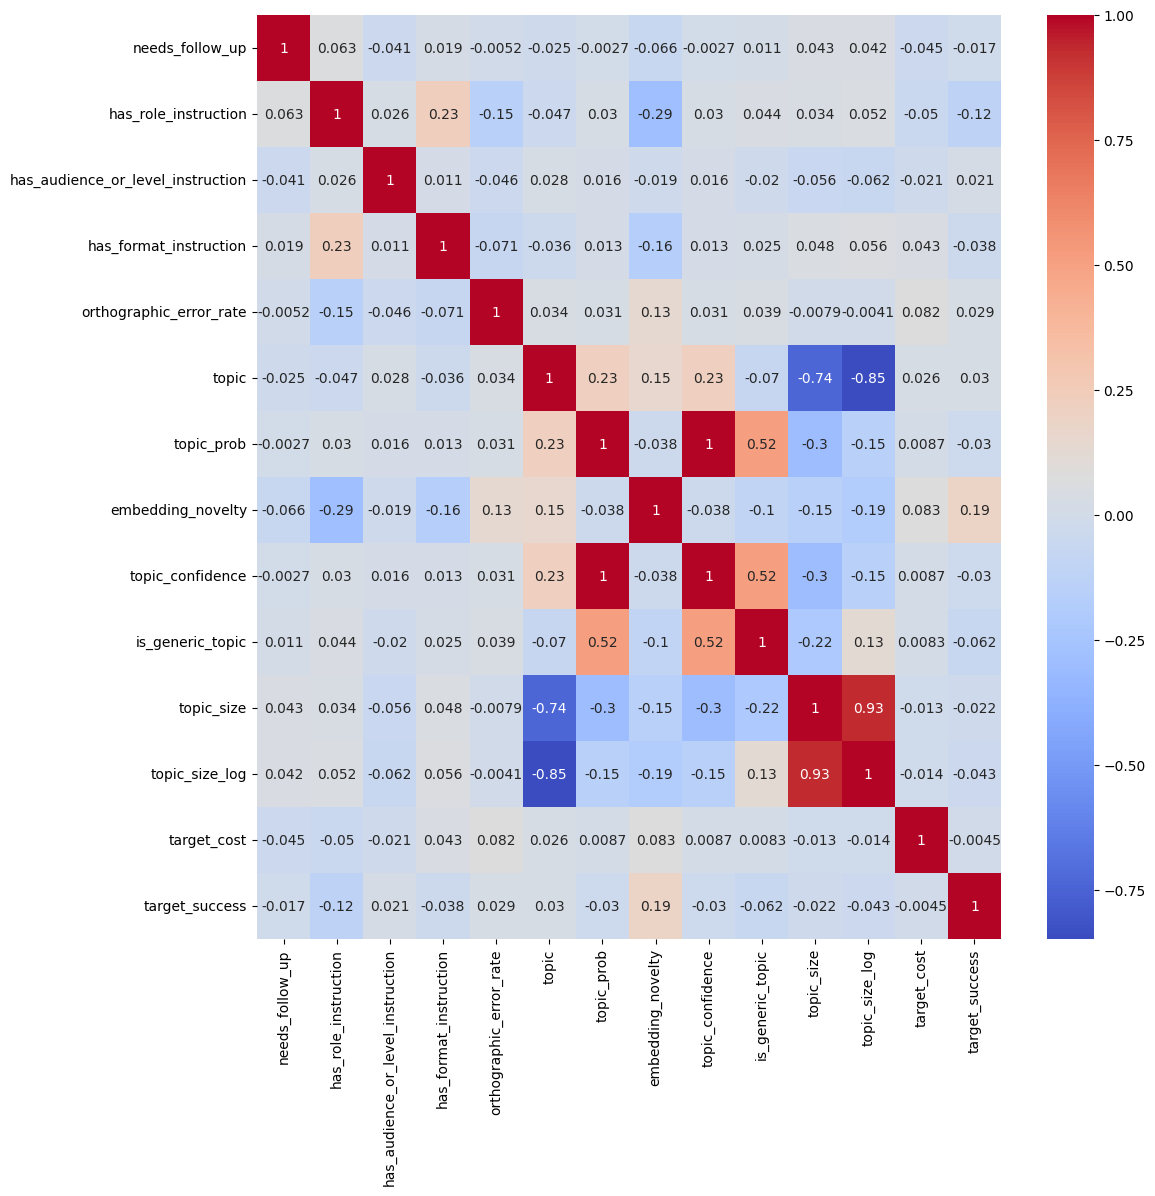

In [7]:
# correlations

fig, ax=plt.subplots(figsize=(12,12))

sns.heatmap(df[['needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
        'orthographic_error_rate', 'topic', 'topic_prob',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success']].corr(), cmap="coolwarm", annot=True)

# train test split

In [8]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)


features_train_emb = embeddings_all[df_train.index]
features_test_emb  = embeddings_all[df_test.index]

In [9]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success',
       'topic_name', 'target_cost_log'],
      dtype='str')

# feature selection

In [10]:
# features selection v01
  
FEATURES_SELECTED_v01 = {
    'cat': [
        "task_type",
        "topic_name",
        ],
    'num': [
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
        "topic_confidence",
        "topic_size_log"
        ],
    'bin': [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
        ]
}

# drop: question_count, total_turns, interaction_rounds, total_user_tokens, total_assistant_tokens, total_tokens, log_total_tokens

# baseline logistic regression modell "target_success" without embeddings

In [17]:
# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v01['cat']
    + FEATURES_SELECTED_v01['num']
    + FEATURES_SELECTED_v01['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_SELECTED_v01['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v01['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v01['cat']),
    ],
    remainder="drop"
)

# model
model_reg_01 = LogisticRegression(random_state=42, max_iter=2000, class_weight="balanced") 

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess), 
    ("model", model_reg_01)
])

# fit model
pipeline.fit(df_train[features_cols], df_train["target_success"])    

# predict test
target_test_success_pred = pipeline.predict(df_test[features_cols])
target_test_success_proba = pipeline.predict_proba(df_test[features_cols])[:, 1]

# metrics
print("Accuracy:", accuracy_score(df_test["target_success"], target_test_success_pred))
print("f1_score:", f1_score(df_test["target_success"], target_test_success_pred))
print("ROC AUC:", roc_auc_score(df_test["target_success"], target_test_success_proba))

Accuracy: 0.6265426733877977
f1_score: 0.7431713585559739
ROC AUC: 0.677399552040287


In [12]:
# names of features

model = pipeline.named_steps["model"]
preprocess = pipeline.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values("coefficient", ascending=False)

print(coef_df.head(40))

                                           feature  coefficient
6           bin__has_audience_or_level_instruction         0.70
14                    cat__task_type_summarization         0.59
24                  cat__topic_name_Travel / Trips         0.52
0                           num__embedding_novelty         0.50
11                      cat__task_type_explanation         0.43
19        cat__topic_name_Git / GitHub Development         0.35
21         cat__topic_name_Medical / Clinical Data         0.34
25                             cat__topic_name_nan         0.31
8                     cat__task_type_brainstorming         0.27
4                              num__topic_size_log         0.19
18               cat__topic_name_Cooking / Recipes         0.13
1                                  num__topic_prob        -0.01
3                            num__topic_confidence        -0.01
2                     num__orthographic_error_rate        -0.01
7                      bin__has_format_i

# global importances

In [13]:
# get names from pipeline
preprocess = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["model"]

features_train_transformed = preprocess.transform(df_train[features_cols])
features_test_transformed = preprocess.transform(df_test[features_cols])

feature_names = preprocess.get_feature_names_out()

# SHAP explainer
explainer = shap.LinearExplainer(
    model,
    features_train_transformed
)

shap_values = explainer(features_test_transformed)


fi_shap = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values("importance", ascending=False)


def original_feature_name(feature):

    # numerische Features
    for col in FEATURES_SELECTED_v01["num"]:
        if feature == f"num__{col}":
            return col

    # binäre Features
    for col in FEATURES_SELECTED_v01["bin"]:
        if feature == f"bin__{col}":
            return col

    # kategorische Features (OHE)
    for col in FEATURES_SELECTED_v01["cat"]:
        if feature.startswith(f"cat__{col}_"):
            return col

    return feature


fi_shap["original_feature"] = (
    fi_shap["feature"]
    .apply(original_feature_name)
)

grouped_importance = (
    fi_shap.groupby("original_feature", as_index=False)["importance"]
           .sum()
           .sort_values("importance", ascending=False)
)

grouped_importance

,original_feature,importance
7,topic_name,0.66
0,embedding_novelty,0.41
5,task_type,0.29
9,topic_size_log,0.11
3,has_role_instruction,0.09
1,has_audience_or_level_instruction,0.01
2,has_format_instruction,0.01
6,topic_confidence,0.01
8,topic_prob,0.01
4,orthographic_error_rate,0.01


# baseline logistic regression modell "target_success" with embeddings

In [14]:
# tabular pipeline
tabular_pipeline = ColumnTransformer( 
    transformers=[ ("num", "passthrough", FEATURES_SELECTED_v01['num']), 
                  ("bin", "passthrough", FEATURES_SELECTED_v01['bin']), 
                  ("cat", OneHotEncoder(handle_unknown="ignore"), 
                   FEATURES_SELECTED_v01['cat']), ], remainder="drop" )

# tabular features
df_train_tab = tabular_pipeline.fit_transform(df_train[features_cols])
df_test_tab = tabular_pipeline.transform(df_test[features_cols])

# add embeddings
features_train = np.hstack([df_train_tab, features_train_emb])
features_test = np.hstack([df_test_tab, features_test_emb])

# initiate model
model_reg_03 = LogisticRegression(random_state=42, max_iter=2000, class_weight="balanced", solver="saga")

# fit modell
model_reg_03.fit(features_train, df_train["target_success"])


# predict
target_test_success_pred = model_reg_03.predict(features_test)
target_test_success_proba = model_reg_03.predict_proba(features_test)[:, 1]


# metrics
print("Accuracy:", accuracy_score(df_test["target_success"], target_test_success_pred))
print("f1_score:", f1_score(df_test["target_success"], target_test_success_pred))
print("ROC AUC:", roc_auc_score(df_test["target_success"], target_test_success_proba))

Accuracy: 0.7079784460281592
f1_score: 0.8066298342541437
ROC AUC: 0.7825604596963263


In [15]:
# names of features

tabular_feature_names = tabular_pipeline.get_feature_names_out()

embedding_feature_names = [
    f"embedding_{i}"
    for i in range(features_train_emb.shape[1])
]

all_feature_names = np.concatenate([
    tabular_feature_names,
    embedding_feature_names
])

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": model_reg_03.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df.sort_values("abs_coefficient", ascending=False).head(50)

,feature,coefficient,abs_coefficient
320,embedding_294,3.47,3.47
166,embedding_140,2.91,2.91
44,embedding_18,2.77,2.77
230,embedding_204,2.67,2.67
242,embedding_216,2.64,2.64
337,embedding_311,-2.63,2.63
305,embedding_279,2.60,2.60
131,embedding_105,-2.54,2.54
324,embedding_298,-2.50,2.50
182,embedding_156,-2.41,2.41


# baseline logistic regression modell "target_success" with embeddings and PCA

In [16]:
model_reg_04 = LogisticRegression(
    random_state=42,
    max_iter=2000,
    class_weight="balanced",
    solver="saga"
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("clf", model_reg_04)
])

pipeline.fit(features_train_emb)
score = pipeline.score(features_test_emb)

ValueError: This LogisticRegression estimator requires y to be passed, but the target y is None.